# Pandas - 데이터 준비하기: 다듬기, 변형, 병합 실습

## 실습 주제
이번 노트북은 강의의 **「Pandas - 데이터 준비하기: 다듬기, 변형, 병합」** 내용을 실제 데이터와 직접 만든 실습용 데이터프레임으로 연결합니다.

## 사용 데이터
- `boston.csv`: 수치형 데이터 다듬기, 파생변수, 이상치, 구간화, 상관분석, 시각화
- `CCTV_in_Seoul.csv`, `CCTV_result.csv`: 실제 데이터 병합, 파생지표, 구별 비교 시각화
- `stock_px.csv`: 시계열 데이터 정리, 정규화, 결측 처리, 선 그래프
- 직접 생성하는 `dirty_customers`, `transactions`: 결측값, 중복, 문자열 정리, 매핑, 병합, 재형성, 피벗 실습

## 학습 목표
1. 데이터 품질을 진단하고 결측값, 중복값, 특이값을 처리한다.
2. `replace`, `map`, `astype`, `to_datetime`, 문자열 메서드를 사용해 데이터를 다듬는다.
3. `assign`, `apply`, `cut`, `qcut`, `melt`, `pivot_table`, `stack`, `unstack`으로 데이터를 변형한다.
4. `merge`, `concat`, `join`, `combine_first`로 여러 데이터셋을 합친다.
5. 준비된 데이터를 막대그래프, 히스토그램, 산점도, 선그래프, 히트맵으로 시각화한다.

---
## 0. 실습 환경 준비

아래 셀은 필요한 라이브러리를 불러오고, 데이터 파일이 현재 폴더 또는 `/mnt/data`에 있을 때 자동으로 찾는 유틸리티 함수를 정의합니다.

In [2]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:


warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 120)
plt.rcParams['axes.unicode_minus'] = False

DATA_CANDIDATES = [
    Path.cwd(),
    Path.cwd() / 'data',
    Path('/mnt/data'),
]

def find_file(filename):
    """현재 작업 폴더, data 폴더, /mnt/data 순서로 파일을 찾는다."""
    for base in DATA_CANDIDATES:
        path = base / filename
        if path.exists():
            return path
    raise FileNotFoundError(f'{filename} 파일을 찾을 수 없습니다. 노트북과 같은 폴더 또는 /mnt/data에 두세요.')

def read_csv_auto(filename, **kwargs):
    """UTF-8, CP949, EUC-KR 순서로 CSV를 읽는다."""
    path = find_file(filename)
    last_error = None
    for enc in ['utf-8', 'cp949', 'euc-kr']:
        try:
            return pd.read_csv(path, encoding=enc, **kwargs)
        except Exception as e:
            last_error = e
    raise last_error

print('pandas version:', pd.__version__)
print('numpy version:', np.__version__)

---
## 1. 실제 데이터 불러오기와 기본 구조 확인

데이터 준비의 첫 단계는 파일을 읽고, 행/열 구조, 자료형, 결측 여부를 확인하는 것입니다.

In [ ]:
boston = read_csv_auto('boston.csv')
cctv_in = read_csv_auto('CCTV_in_Seoul.csv')
cctv_result = read_csv_auto('CCTV_result.csv')
stock_px = read_csv_auto('stock_px.csv')

print('boston:', boston.shape)
print('cctv_in:', cctv_in.shape)
print('cctv_result:', cctv_result.shape)
print('stock_px:', stock_px.shape)

In [ ]:
boston.head()

In [ ]:
cctv_in.head()

In [ ]:
stock_px.head()

In [ ]:
# DataFrame 구조 확인
boston.info()

In [ ]:
# 수치형 컬럼의 요약 통계
boston.describe().T

---
## 2. 실습용 더러운 데이터프레임 만들기

실무 데이터에는 다음과 같은 문제가 자주 존재합니다.

- 같은 고객이 중복 입력됨
- `UNKNOWN`, `N/A`, `-999` 같은 결측 대체 문자열이나 특수값이 섞임
- 문자열 앞뒤 공백, 대소문자 불일치
- 성별 코드가 `M`, `Male`, `Female`, `m`처럼 혼재
- 음수 나이, 비정상적으로 큰 나이 같은 오류값 존재
- 월별 금액 컬럼이 넓은 형태로 저장되어 분석이 불편함

In [3]:
dirty_customers = pd.DataFrame({
    'customer_id': ['C001', 'C002', 'C003', 'C004', 'C005', 'C006', 'C006', 'C007', 'C008', 'C009', 'C010', 'C011'],
    'name': [' Alice ', 'Bob', 'Choi', 'Dana', 'Eun', 'Frank', 'Frank', None, 'Hana', 'Ian', 'Jin', 'Kang'],
    'gender': ['M', 'F', 'm', 'Female', 'UNKNOWN', 'F', 'F', 'M', 'N/A', 'Male', 'F', 'M'],
    'region': ['Seoul', 'seoul ', 'Busan', 'Incheon', 'Daegu', 'Seoul', 'Seoul', 'UNKNOWN', 'Daejeon', 'Busan', None, 'Seoul'],
    'age': [29, 41, -1, 35, np.nan, 52, 52, 120, 37, 45, 33, 28],
    'spend_jan': [120000, 85000, np.nan, 450000, -999, 98000, 98000, 130000, 210000, np.nan, 76000, 305000],
    'spend_feb': [135000, np.nan, 99000, 500000, 120000, 110000, 110000, 125000, -999, 230000, 80000, 310000],
    'spend_mar': [128000, 92000, 101000, 470000, 125000, 108000, 108000, np.nan, 220000, 240000, -999, 330000],
    'join_date': ['2024-01-03', '2024/02/15', '2024-03-20', '2024-01-12', 'not_date', '2024-02-01', '2024-02-01',
                  '2024-04-05', '2024-03-01', '2024-04-10', '2024-02-28', '2024-01-25']
})

dirty_customers

,customer_id,name,gender,region,age,spend_jan,spend_feb,spend_mar,join_date
0,C001,Alice,M,Seoul,29.0,120000.0,135000.0,128000.0,2024-01-03
1,C002,Bob,F,seoul,41.0,85000.0,NaN,92000.0,2024/02/15
2,C003,Choi,m,Busan,-1.0,NaN,99000.0,101000.0,2024-03-20
3,C004,Dana,Female,Incheon,35.0,450000.0,500000.0,470000.0,2024-01-12
4,C005,Eun,UNKNOWN,Daegu,NaN,-999.0,120000.0,125000.0,not_date
5,C006,Frank,F,Seoul,52.0,98000.0,110000.0,108000.0,2024-02-01
6,C006,Frank,F,Seoul,52.0,98000.0,110000.0,108000.0,2024-02-01
7,C007,NaN,M,UNKNOWN,120.0,130000.0,125000.0,NaN,2024-04-05
8,C008,Hana,N/A,Daejeon,37.0,210000.0,-999.0,220000.0,2024-03-01
9,C009,Ian,Male,Busan,45.0,NaN,230000.0,240000.0,2024-04-10


In [4]:
# 데이터 품질 진단 1: 자료형, 결측, 중복
print('shape:', dirty_customers.shape)
print('\n결측 개수')
display(dirty_customers.isna().sum())
print('\n중복 여부')
display(dirty_customers.duplicated())
print('\n요약')
display(dirty_customers.describe(include='all'))

shape: (12, 9)

결측 개수


customer_id    0
name           1
gender         0
region         1
age            1
spend_jan      2
spend_feb      1
spend_mar      1
join_date      0
dtype: int64


중복 여부


0     False
1     False
2     False
3     False
4     False
5     False
6      True
7     False
8     False
9     False
10    False
11    False
dtype: bool


요약


,customer_id,name,gender,region,age,spend_jan,spend_feb,spend_mar,join_date
count,12,11,12,11,11.000000,10.000000,11.000000,11.000000,12
unique,11,10,7,7,NaN,NaN,NaN,NaN,11
top,C006,Frank,F,Seoul,NaN,NaN,NaN,NaN,2024-02-01
freq,2,2,4,4,NaN,NaN,NaN,NaN,2
mean,NaN,NaN,NaN,NaN,42.818182,157100.100000,165272.818182,174636.454545,NaN
std,NaN,NaN,NaN,NaN,29.420463,131795.541908,136815.879661,132032.645275,NaN
min,NaN,NaN,NaN,NaN,-1.000000,-999.000000,-999.000000,-999.000000,NaN
25%,NaN,NaN,NaN,NaN,31.000000,88250.000000,104500.000000,104500.000000,NaN
50%,NaN,NaN,NaN,NaN,37.000000,109000.000000,120000.000000,125000.000000,NaN
75%,NaN,NaN,NaN,NaN,48.500000,190000.000000,182500.000000,230000.000000,NaN


In [39]:
# 정제 전에 먼저 프로파일링(profiling)
# -999, UNKNOWN, N/A처럼 결측을 의미하지만 아직 결측으로 인식되지 않는 값 확인
for col in dirty_customers.columns:
    print(f'[{col}]') # 현재 컬럼명 출력
    print(dirty_customers[col].value_counts(dropna=False)) # 값 빈도수 계산, 결측치도 포함(dropna=False)
    print('-' * 60)

[customer_id]
customer_id
C006    2
C001    1
C002    1
C003    1
C004    1
C005    1
C007    1
C008    1
C009    1
C010    1
C011    1
Name: count, dtype: int64
------------------------------------------------------------
[name]
name
Frank      2
 Alice     1
Bob        1
Choi       1
Dana       1
Eun        1
NaN        1
Hana       1
Ian        1
Jin        1
Kang       1
Name: count, dtype: int64
------------------------------------------------------------
[gender]
gender
F          4
M          3
m          1
Female     1
UNKNOWN    1
N/A        1
Male       1
Name: count, dtype: int64
------------------------------------------------------------
[region]
region
Seoul      4
Busan      2
seoul      1
Incheon    1
Daegu      1
UNKNOWN    1
Daejeon    1
NaN        1
Name: count, dtype: int64
------------------------------------------------------------
[age]
age
 52.0     2
 29.0     1
 41.0     1
-1.0      1
 35.0     1
 NaN      1
 120.0    1
 37.0     1
 45.0     1
 33.0     1
 28.

---
## 3. 다듬기 1: 중복 제거와 문자열 정리

`duplicated()`는 각 행이 중복인지 여부를 반환하고, `drop_duplicates()`는 중복 행을 제거합니다.
문자열 컬럼은 `.str.strip()`, `.str.title()`, `.str.upper()` 등을 사용해 표기 불일치를 줄입니다.

In [37]:
clean = dirty_customers.copy()

# 완전히 동일한 중복 행 제거
print('중복 제거 전:', clean.shape)
clean = clean.drop_duplicates()
print('중복 제거 후:', clean.shape)

clean

중복 제거 전: (12, 9)
중복 제거 후: (11, 9)


,customer_id,name,gender,region,age,spend_jan,spend_feb,spend_mar,join_date
0,C001,Alice,M,Seoul,29.0,120000.0,135000.0,128000.0,2024-01-03
1,C002,Bob,F,seoul,41.0,85000.0,NaN,92000.0,2024/02/15
2,C003,Choi,m,Busan,-1.0,NaN,99000.0,101000.0,2024-03-20
3,C004,Dana,Female,Incheon,35.0,450000.0,500000.0,470000.0,2024-01-12
4,C005,Eun,UNKNOWN,Daegu,NaN,-999.0,120000.0,125000.0,not_date
5,C006,Frank,F,Seoul,52.0,98000.0,110000.0,108000.0,2024-02-01
7,C007,NaN,M,UNKNOWN,120.0,130000.0,125000.0,NaN,2024-04-05
8,C008,Hana,N/A,Daejeon,37.0,210000.0,-999.0,220000.0,2024-03-01
9,C009,Ian,Male,Busan,45.0,NaN,230000.0,240000.0,2024-04-10
10,C010,Jin,F,NaN,33.0,76000.0,80000.0,-999.0,2024-02-28


In [38]:
# 이름과 지역 문자열 정리
clean['name'] = clean['name'].str.strip()
clean['region'] = clean['region'].replace({'UNKNOWN': np.nan, 'N/A': np.nan})
clean['region'] = clean['region'].str.strip().str.title()

# 성별 표기 정리: M/m/Male -> M, F/Female -> F
clean['gender'] = clean['gender'].replace({'UNKNOWN': np.nan, 'N/A': np.nan})
clean['gender'] = clean['gender'].str.strip().str.upper()
clean['gender'] = clean['gender'].replace({'MALE': 'M', 'FEMALE': 'F'})

clean[['customer_id', 'name', 'gender', 'region']]

,customer_id,name,gender,region
0,C001,Alice,M,Seoul
1,C002,Bob,F,Seoul
2,C003,Choi,M,Busan
3,C004,Dana,F,Incheon
4,C005,Eun,NaN,Daegu
5,C006,Frank,F,Seoul
7,C007,NaN,M,NaN
8,C008,Hana,NaN,Daejeon
9,C009,Ian,M,Busan
10,C010,Jin,F,NaN


---
## 4. 다듬기 2: 특수값 치환, 자료형 변환, 결측값 처리

`replace()`는 특정 값을 다른 값으로 바꾸는 데 유용합니다. 여기서는 금액 컬럼의 `-999`를 결측값으로 바꿉니다.
`pd.to_datetime()`은 날짜 문자열을 날짜형으로 변환하고, 변환 실패값은 `NaT`로 처리할 수 있습니다.

In [8]:
spend_cols = ['spend_jan', 'spend_feb', 'spend_mar']

# -999는 실제 금액이 아니라 결측을 의미한다고 가정
clean[spend_cols] = clean[spend_cols].replace(-999, np.nan)

# 날짜 변환: 변환 실패는 NaT
clean['join_date'] = pd.to_datetime(clean['join_date'], errors='coerce')

# 나이 오류값 처리: 0~100 범위를 벗어나면 결측으로 간주
clean['age'] = clean['age'].where(clean['age'].between(0, 100), np.nan)

clean

,customer_id,name,gender,region,age,spend_jan,spend_feb,spend_mar,join_date
0,C001,Alice,M,Seoul,29.0,120000.0,135000.0,128000.0,2024-01-03
1,C002,Bob,F,Seoul,41.0,85000.0,NaN,92000.0,NaT
2,C003,Choi,M,Busan,NaN,NaN,99000.0,101000.0,2024-03-20
3,C004,Dana,F,Incheon,35.0,450000.0,500000.0,470000.0,2024-01-12
4,C005,Eun,NaN,Daegu,NaN,NaN,120000.0,125000.0,NaT
5,C006,Frank,F,Seoul,52.0,98000.0,110000.0,108000.0,2024-02-01
7,C007,NaN,M,NaN,NaN,130000.0,125000.0,NaN,2024-04-05
8,C008,Hana,NaN,Daejeon,37.0,210000.0,NaN,220000.0,2024-03-01
9,C009,Ian,M,Busan,45.0,NaN,230000.0,240000.0,2024-04-10
10,C010,Jin,F,NaN,33.0,76000.0,80000.0,NaN,2024-02-28


In [10]:
# 결측값의 카운트
clean.isna().sum().sort_values(ascending=False)

age            3
spend_jan      3
spend_mar      2
region         2
gender         2
join_date      2
spend_feb      2
name           1
customer_id    0
dtype: int64

In [41]:
# 결측 여부 자체가 의미 있을 수 있으므로 flag 변수 생성
# age, region, join_date, 그리고 spend_cols에 있는 컬럼들을 순회
for col in ['age', 'region', 'join_date'] + spend_cols:
    clean[f'{col}_missing'] = clean[col].isna().astype(int)
    # 결측치 여부를 나타내는 새로운 컬럼 생성
    # isna()      : 결측치이면 True, 아니면 False
    # astype(int) : True → 1, False → 0 변환

clean.filter(regex='missing$').head() # 컬럼명이 'missing'으로 끝나는 컬럼만 선택

,age_missing,region_missing,join_date_missing,spend_jan_missing,spend_feb_missing,spend_mar_missing
0,0,0,0,0,0,0
1,0,0,0,0,1,0
2,0,0,0,1,0,0
3,0,0,0,0,0,0
4,1,0,0,0,0,0


In [42]:
# 수치형 결측값은 중앙값으로 대체, 범주형 결측값은 Unknown으로 대체
clean['age'] = clean['age'].fillna(clean['age'].median())
for col in spend_cols:
    clean[col] = clean[col].fillna(clean[col].median())

clean['region'] = clean['region'].fillna('Unknown')
clean['gender'] = clean['gender'].fillna('U')
clean['join_date'] = clean['join_date'].fillna(pd.Timestamp('2024-01-01'))

clean.isna().sum().sort_values(ascending=False).head(10)

name           1
customer_id    0
gender         0
region         0
age            0
spend_jan      0
spend_feb      0
spend_mar      0
join_date      0
age_missing    0
dtype: int64

### 결측 처리 전후 분포 비교
결측값을 채우면 분석은 쉬워지지만, 분포가 달라질 수 있습니다. 따라서 대체 전후를 시각적으로 확인하는 것이 좋습니다.

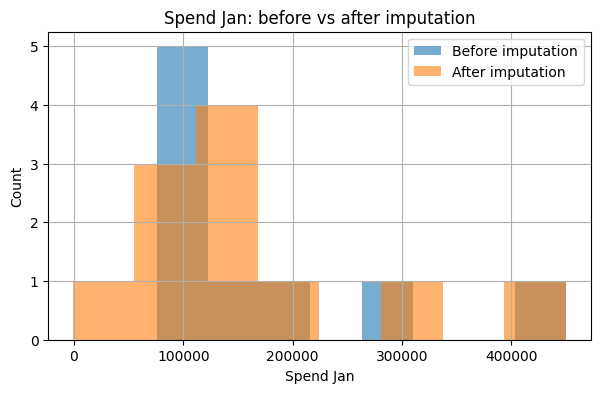

In [43]:
original_spend_jan = pd.to_numeric(dirty_customers['spend_jan'].replace(-999, np.nan), errors='coerce')

plt.figure(figsize=(7, 4))
original_spend_jan.hist(alpha=0.6, bins=8, label='Before imputation')
clean['spend_jan'].hist(alpha=0.6, bins=8, label='After imputation')
plt.title('Spend Jan: before vs after imputation')
plt.xlabel('Spend Jan')
plt.ylabel('Count')
plt.legend()
plt.show()

---
## 5. 다듬기 3: 매핑, 카테고리 변환, 파생변수 만들기

`map()`은 코드값을 사람이 이해하기 쉬운 라벨로 바꿀 때 자주 사용합니다.
`assign()`은 기존 컬럼을 이용해 새로운 컬럼을 만들 때 유용합니다.

In [14]:
gender_map = {'M': '남성', 'F': '여성', 'U': '미상'}
region_group_map = {
    'Seoul': '수도권',
    'Incheon': '수도권',
    'Busan': '비수도권',
    'Daegu': '비수도권',
    'Daejeon': '비수도권',
    'Unknown': '미상'
}

clean['gender_label'] = clean['gender'].map(gender_map)
clean['region_group'] = clean['region'].map(region_group_map).fillna('기타')
clean['region'] = clean['region'].astype('category')
clean['gender_label'] = clean['gender_label'].astype('category')

clean[['customer_id', 'gender', 'gender_label', 'region', 'region_group']]

,customer_id,gender,gender_label,region,region_group
0,C001,M,남성,Seoul,수도권
1,C002,F,여성,Seoul,수도권
2,C003,M,남성,Busan,비수도권
3,C004,F,여성,Incheon,수도권
4,C005,U,미상,Daegu,비수도권
5,C006,F,여성,Seoul,수도권
7,C007,M,남성,Unknown,미상
8,C008,U,미상,Daejeon,비수도권
9,C009,M,남성,Busan,비수도권
10,C010,F,여성,Unknown,미상


In [15]:
clean = clean.assign(
    total_spend = clean[spend_cols].sum(axis=1),
    avg_spend = clean[spend_cols].mean(axis=1),
    spend_growth = clean['spend_mar'] - clean['spend_jan'],
    high_value = np.where(clean[spend_cols].sum(axis=1) >= 500000, '우수고객', '일반고객')
)

clean[['customer_id', 'total_spend', 'avg_spend', 'spend_growth', 'high_value']].sort_values('total_spend', ascending=False)

,customer_id,total_spend,avg_spend,spend_growth,high_value
3,C004,1420000.0,473333.333333,20000.0,우수고객
11,C011,945000.0,315000.000000,25000.0,우수고객
9,C009,595000.0,198333.333333,115000.0,우수고객
8,C008,555000.0,185000.000000,10000.0,우수고객
7,C007,383000.0,127666.666667,-2000.0,일반고객
0,C001,383000.0,127666.666667,8000.0,일반고객
4,C005,370000.0,123333.333333,0.0,일반고객
2,C003,325000.0,108333.333333,-24000.0,일반고객
5,C006,316000.0,105333.333333,10000.0,일반고객
1,C002,302000.0,100666.666667,7000.0,일반고객


---
## 6. apply 실습: 행/열 단위 함수 적용

`apply()`는 행 또는 열 단위로 사용자 정의 함수를 적용할 때 사용합니다.
- `axis=0`: 열 단위 적용
- `axis=1`: 행 단위 적용

In [16]:
def spend_range(row):
    """월별 지출액의 최대-최소 차이를 계산한다."""
    return row[spend_cols].max() - row[spend_cols].min()

clean['spend_range'] = clean.apply(spend_range, axis=1)
clean[['customer_id', 'spend_jan', 'spend_feb', 'spend_mar', 'spend_range']]

,customer_id,spend_jan,spend_feb,spend_mar,spend_range
0,C001,120000.0,135000.0,128000.0,15000.0
1,C002,85000.0,125000.0,92000.0,40000.0
2,C003,125000.0,99000.0,101000.0,26000.0
3,C004,450000.0,500000.0,470000.0,50000.0
4,C005,125000.0,120000.0,125000.0,5000.0
5,C006,98000.0,110000.0,108000.0,12000.0
7,C007,130000.0,125000.0,128000.0,5000.0
8,C008,210000.0,125000.0,220000.0,95000.0
9,C009,125000.0,230000.0,240000.0,115000.0
10,C010,76000.0,80000.0,128000.0,52000.0


In [17]:
# 열 단위 apply: 각 월별 지출액의 범위 계산
clean[spend_cols].apply(lambda x: x.max() - x.min(), axis=0)

spend_jan    374000.0
spend_feb    420000.0
spend_mar    378000.0
dtype: float64

---
## 7. 변형 1: wide → long 변환(melt)

월별 지출액이 `spend_jan`, `spend_feb`, `spend_mar`처럼 여러 컬럼으로 펼쳐져 있으면 시계열/그룹 분석이 불편할 수 있습니다.
`melt()`를 사용하면 넓은 형태(wide)를 긴 형태(long)로 바꿀 수 있습니다.

In [19]:
spend_long = clean.melt(
    id_vars=['customer_id', 'name', 'gender_label', 'region', 'region_group', 'high_value'],
    value_vars=spend_cols,
    var_name='month',
    value_name='spend'
)

spend_long.head(12)

,customer_id,name,gender_label,region,region_group,high_value,month,spend
0,C001,Alice,남성,Seoul,수도권,일반고객,spend_jan,120000.0
1,C002,Bob,여성,Seoul,수도권,일반고객,spend_jan,85000.0
2,C003,Choi,남성,Busan,비수도권,일반고객,spend_jan,125000.0
3,C004,Dana,여성,Incheon,수도권,우수고객,spend_jan,450000.0
4,C005,Eun,미상,Daegu,비수도권,일반고객,spend_jan,125000.0
5,C006,Frank,여성,Seoul,수도권,일반고객,spend_jan,98000.0
6,C007,NaN,남성,Unknown,미상,일반고객,spend_jan,130000.0
7,C008,Hana,미상,Daejeon,비수도권,우수고객,spend_jan,210000.0
8,C009,Ian,남성,Busan,비수도권,우수고객,spend_jan,125000.0
9,C010,Jin,여성,Unknown,미상,일반고객,spend_jan,76000.0


In [ ]:
# month 값을 더 보기 좋은 라벨로 변환
month_map = {'spend_jan': '2024-01', 'spend_feb': '2024-02', 'spend_mar': '2024-03'}
spend_long['month'] = spend_long['month'].map(month_map)
spend_long.head()

---
## 8. 변형 2: groupby와 pivot_table

`pivot_table()`은 `groupby + 집계 + unstack`을 보고서형 2차원 표로 만드는 데 유용합니다.

In [20]:
# 그룹별 월별 평균 지출액
monthly_region = spend_long.groupby(['region_group', 'month'])['spend'].mean().reset_index()
monthly_region

,region_group,month,spend
0,미상,spend_feb,102500.0
1,미상,spend_jan,103000.0
2,미상,spend_mar,128000.0
3,비수도권,spend_feb,143500.0
4,비수도권,spend_jan,146250.0
5,비수도권,spend_mar,171500.0
6,수도권,spend_feb,236000.0
7,수도권,spend_jan,211600.0
8,수도권,spend_mar,225600.0


In [21]:
# pivot_table: 지역그룹 x 월 형태의 요약표
spend_pivot = pd.pivot_table(
    spend_long,
    values='spend',
    index='region_group',
    columns='month',
    aggfunc='mean',
    fill_value=0,
    margins=True,
    margins_name='전체평균'
)

spend_pivot

month,spend_feb,spend_jan,spend_mar,전체평균
region_group,,,,
미상,102500.000000,103000.000000,128000.000000,111166.666667
비수도권,143500.000000,146250.000000,171500.000000,153750.000000
수도권,236000.000000,211600.000000,225600.000000,224400.000000
전체평균,178090.909091,168090.909091,188181.818182,178121.212121


In [22]:
# stack / unstack 기본 예시
stacked = spend_pivot.drop(index='전체평균', errors='ignore').stack()
print('stack 결과')
display(stacked.head(10))

print('unstack 결과')
display(stacked.unstack())

stack 결과


region_group  month    
미상            spend_feb    102500.000000
              spend_jan    103000.000000
              spend_mar    128000.000000
              전체평균         111166.666667
비수도권          spend_feb    143500.000000
              spend_jan    146250.000000
              spend_mar    171500.000000
              전체평균         153750.000000
수도권           spend_feb    236000.000000
              spend_jan    211600.000000
dtype: float64

unstack 결과


month,spend_feb,spend_jan,spend_mar,전체평균
region_group,,,,
미상,102500.0,103000.0,128000.0,111166.666667
비수도권,143500.0,146250.0,171500.0,153750.000000
수도권,236000.0,211600.0,225600.0,224400.000000


### 피벗 결과 시각화

C:\Users\user\AppData\Local\Temp\ipykernel_10972\389271027.py:9: UserWarning: Glyph 48120 (\N{HANGUL SYLLABLE MI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_10972\389271027.py:9: UserWarning: Glyph 49345 (\N{HANGUL SYLLABLE SANG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_10972\389271027.py:9: UserWarning: Glyph 48708 (\N{HANGUL SYLLABLE BI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_10972\389271027.py:9: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_10972\389271027.py:9: UserWarning: Glyph 46020 (\N{HANGUL SYLLABLE DO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_10972\389271027.py:9: UserWarning: Glyph 44428 (\N{HANGUL SYLLABLE GWEON}) missing from font(s) DejaVu Sa

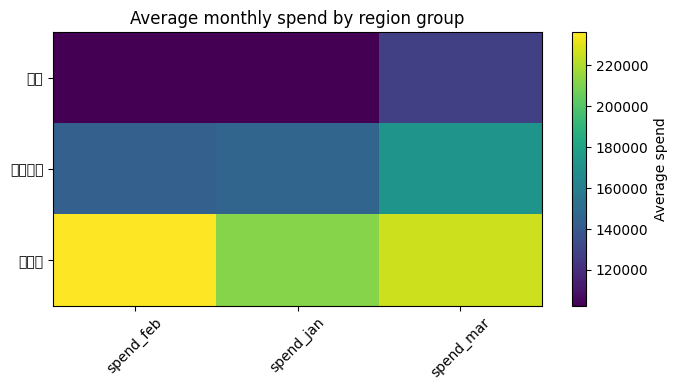

In [23]:
plot_pivot = spend_pivot.drop(index='전체평균', errors='ignore').drop(columns='전체평균', errors='ignore')

plt.figure(figsize=(7, 4))
plt.imshow(plot_pivot.values, aspect='auto')
plt.xticks(range(len(plot_pivot.columns)), plot_pivot.columns, rotation=45)
plt.yticks(range(len(plot_pivot.index)), plot_pivot.index)
plt.colorbar(label='Average spend')
plt.title('Average monthly spend by region group')
plt.tight_layout()
plt.show()

---
## 9. 병합 1: concat으로 여러 거래 파일 합치기

하나의 데이터셋이 여러 파일로 나누어져 있을 때 `pd.concat()`으로 행 방향 결합을 수행합니다.

In [24]:
transactions_q1 = pd.DataFrame({
    'order_id': ['O001', 'O002', 'O003', 'O004', 'O005'],
    'customer_id': ['C001', 'C002', 'C004', 'C006', 'C099'],
    'order_month': ['2024-01', '2024-01', '2024-02', '2024-02', '2024-02'],
    'amount': [120000, 85000, 240000, 98000, 50000]
})

transactions_q2 = pd.DataFrame({
    'order_id': ['O006', 'O007', 'O008', 'O009'],
    'customer_id': ['C001', 'C003', 'C008', 'C011'],
    'order_month': ['2024-03', '2024-03', '2024-03', '2024-03'],
    'amount': [128000, 101000, 220000, 330000]
})

transactions = pd.concat([transactions_q1, transactions_q2], ignore_index=True)
transactions

,order_id,customer_id,order_month,amount
0,O001,C001,2024-01,120000
1,O002,C002,2024-01,85000
2,O003,C004,2024-02,240000
3,O004,C006,2024-02,98000
4,O005,C099,2024-02,50000
5,O006,C001,2024-03,128000
6,O007,C003,2024-03,101000
7,O008,C008,2024-03,220000
8,O009,C011,2024-03,330000


In [ ]:
# keys 옵션을 사용하면 원본 출처를 계층적 인덱스로 남길 수 있음
transactions_with_key = pd.concat({'Q1': transactions_q1, 'Q2': transactions_q2})
transactions_with_key

---
## 10. 병합 2: merge로 고객 정보와 거래 정보 결합

`merge()`는 관계형 데이터베이스의 join과 유사합니다. 키 컬럼을 기준으로 두 DataFrame을 결합합니다.

- `how='inner'`: 양쪽에 모두 존재하는 키만 유지
- `how='left'`: 왼쪽 DataFrame의 행을 모두 유지
- `how='outer'`: 양쪽 모든 키 유지
- `indicator=True`: 병합 출처 확인
- `validate`: 병합 관계 검증 (`m:1`, `1:1` 등)

In [25]:
customer_master = clean[['customer_id', 'name', 'gender_label', 'region', 'region_group', 'age', 'high_value']].copy()
customer_master

,customer_id,name,gender_label,region,region_group,age,high_value
0,C001,Alice,남성,Seoul,수도권,29.0,일반고객
1,C002,Bob,여성,Seoul,수도권,41.0,일반고객
2,C003,Choi,남성,Busan,비수도권,36.0,일반고객
3,C004,Dana,여성,Incheon,수도권,35.0,우수고객
4,C005,Eun,미상,Daegu,비수도권,36.0,일반고객
5,C006,Frank,여성,Seoul,수도권,52.0,일반고객
7,C007,NaN,남성,Unknown,미상,36.0,일반고객
8,C008,Hana,미상,Daejeon,비수도권,37.0,우수고객
9,C009,Ian,남성,Busan,비수도권,45.0,우수고객
10,C010,Jin,여성,Unknown,미상,33.0,일반고객


In [26]:
merged_left = pd.merge(
    transactions,
    customer_master,
    on='customer_id',
    how='left',
    indicator=True,
    validate='m:1'
)

merged_left

,order_id,customer_id,order_month,amount,name,gender_label,region,region_group,age,high_value,_merge
0,O001,C001,2024-01,120000,Alice,남성,Seoul,수도권,29.0,일반고객,both
1,O002,C002,2024-01,85000,Bob,여성,Seoul,수도권,41.0,일반고객,both
2,O003,C004,2024-02,240000,Dana,여성,Incheon,수도권,35.0,우수고객,both
3,O004,C006,2024-02,98000,Frank,여성,Seoul,수도권,52.0,일반고객,both
4,O005,C099,2024-02,50000,NaN,NaN,NaN,NaN,NaN,NaN,left_only
5,O006,C001,2024-03,128000,Alice,남성,Seoul,수도권,29.0,일반고객,both
6,O007,C003,2024-03,101000,Choi,남성,Busan,비수도권,36.0,일반고객,both
7,O008,C008,2024-03,220000,Hana,미상,Daejeon,비수도권,37.0,우수고객,both
8,O009,C011,2024-03,330000,Kang,남성,Seoul,수도권,28.0,우수고객,both


In [27]:
# 매칭되지 않은 거래 확인: C099는 고객 마스터에 없음
merged_left[merged_left['_merge'] != 'both']

,order_id,customer_id,order_month,amount,name,gender_label,region,region_group,age,high_value,_merge
4,O005,C099,2024-02,50000,NaN,NaN,NaN,NaN,NaN,NaN,left_only


In [28]:
# inner join은 고객 마스터에 없는 C099 거래를 제거함
merged_inner = pd.merge(transactions, customer_master, on='customer_id', how='inner', validate='m:1')
print('left join:', merged_left.shape)
print('inner join:', merged_inner.shape)
merged_inner

left join: (9, 11)
inner join: (8, 10)


,order_id,customer_id,order_month,amount,name,gender_label,region,region_group,age,high_value
0,O001,C001,2024-01,120000,Alice,남성,Seoul,수도권,29.0,일반고객
1,O002,C002,2024-01,85000,Bob,여성,Seoul,수도권,41.0,일반고객
2,O003,C004,2024-02,240000,Dana,여성,Incheon,수도권,35.0,우수고객
3,O004,C006,2024-02,98000,Frank,여성,Seoul,수도권,52.0,일반고객
4,O006,C001,2024-03,128000,Alice,남성,Seoul,수도권,29.0,일반고객
5,O007,C003,2024-03,101000,Choi,남성,Busan,비수도권,36.0,일반고객
6,O008,C008,2024-03,220000,Hana,미상,Daejeon,비수도권,37.0,우수고객
7,O009,C011,2024-03,330000,Kang,남성,Seoul,수도권,28.0,우수고객


In [29]:
# outer join: 고객 또는 거래 한쪽에만 있는 키도 모두 확인
merged_outer = pd.merge(transactions, customer_master, on='customer_id', how='outer', indicator=True)
merged_outer['_merge'].value_counts()

_merge
both          8
right_only    4
left_only     1
Name: count, dtype: int64

---
## 11. 병합 3: 컬럼명이 다른 경우의 merge와 join

서로 다른 데이터셋에서 같은 의미의 키가 다른 컬럼명으로 저장되는 경우가 많습니다.
이때는 `left_on`, `right_on`을 사용합니다.

In [30]:
loyalty = pd.DataFrame({
    'member_id': ['C001', 'C002', 'C004', 'C006', 'C008', 'C011'],
    'grade': ['Gold', 'Silver', 'VIP', 'Silver', 'Gold', 'VIP'],
    'point': [1200, 400, 5200, 800, 1700, 6100]
})

customer_loyalty = pd.merge(
    customer_master,
    loyalty,
    left_on='customer_id',
    right_on='member_id',
    how='left'
)

customer_loyalty.head(10)

,customer_id,name,gender_label,region,region_group,age,high_value,member_id,grade,point
0,C001,Alice,남성,Seoul,수도권,29.0,일반고객,C001,Gold,1200.0
1,C002,Bob,여성,Seoul,수도권,41.0,일반고객,C002,Silver,400.0
2,C003,Choi,남성,Busan,비수도권,36.0,일반고객,NaN,NaN,NaN
3,C004,Dana,여성,Incheon,수도권,35.0,우수고객,C004,VIP,5200.0
4,C005,Eun,미상,Daegu,비수도권,36.0,일반고객,NaN,NaN,NaN
5,C006,Frank,여성,Seoul,수도권,52.0,일반고객,C006,Silver,800.0
6,C007,NaN,남성,Unknown,미상,36.0,일반고객,NaN,NaN,NaN
7,C008,Hana,미상,Daejeon,비수도권,37.0,우수고객,C008,Gold,1700.0
8,C009,Ian,남성,Busan,비수도권,45.0,우수고객,NaN,NaN,NaN
9,C010,Jin,여성,Unknown,미상,33.0,일반고객,NaN,NaN,NaN


In [31]:
# index 기반 결합: join
customer_indexed = customer_master.set_index('customer_id')
loyalty_indexed = loyalty.set_index('member_id')

customer_joined = customer_indexed.join(loyalty_indexed, how='left')
customer_joined.head()

,name,gender_label,region,region_group,age,high_value,grade,point
customer_id,,,,,,,,
C001,Alice,남성,Seoul,수도권,29.0,일반고객,Gold,1200.0
C002,Bob,여성,Seoul,수도권,41.0,일반고객,Silver,400.0
C003,Choi,남성,Busan,비수도권,36.0,일반고객,NaN,NaN
C004,Dana,여성,Incheon,수도권,35.0,우수고객,VIP,5200.0
C005,Eun,미상,Daegu,비수도권,36.0,일반고객,NaN,NaN


---
## 12. combine_first: 한쪽 결측값을 다른 데이터로 보완하기

`combine_first()`는 두 객체를 포개서, 앞 객체의 결측값을 뒤 객체의 값으로 채우는 데 유용합니다.

In [32]:
profile_a = pd.DataFrame({
    'customer_id': ['C001', 'C002', 'C003', 'C004'],
    'email': ['a@example.com', np.nan, 'c@example.com', np.nan],
    'phone': [np.nan, '010-2222-2222', np.nan, '010-4444-4444']
}).set_index('customer_id')

profile_b = pd.DataFrame({
    'customer_id': ['C001', 'C002', 'C003', 'C004'],
    'email': ['alice@backup.com', 'bob@backup.com', np.nan, 'dana@backup.com'],
    'phone': ['010-1111-1111', np.nan, '010-3333-3333', np.nan]
}).set_index('customer_id')

profile_completed = profile_a.combine_first(profile_b)
print('profile_a')
display(profile_a)
print('profile_b')
display(profile_b)
print('completed')
display(profile_completed)

profile_a


,email,phone
customer_id,,
C001,a@example.com,NaN
C002,NaN,010-2222-2222
C003,c@example.com,NaN
C004,NaN,010-4444-4444


profile_b


,email,phone
customer_id,,
C001,alice@backup.com,010-1111-1111
C002,bob@backup.com,NaN
C003,NaN,010-3333-3333
C004,dana@backup.com,NaN


completed


,email,phone
customer_id,,
C001,a@example.com,010-1111-1111
C002,bob@backup.com,010-2222-2222
C003,c@example.com,010-3333-3333
C004,dana@backup.com,010-4444-4444


---
## 13. 실제 데이터 병합: 서울시 CCTV 데이터 결합

`CCTV_in_Seoul.csv`와 `CCTV_result.csv`는 구 이름을 기준으로 결합할 수 있습니다.
병합 후 인구 1만 명당 CCTV 수, 최근 증가율 등을 계산해 분석합니다.

In [33]:
cctv_base = cctv_in.rename(columns={'기관명': '구별'}).copy()

# 필요한 컬럼만 선택하여 병합
cctv_detail = cctv_result[['구별', '인구수', '고령자비율', '외국인비율', 'CCTV비율', '오차']].copy()

cctv_merged = pd.merge(cctv_base, cctv_detail, on='구별', how='inner', validate='1:1')
cctv_merged['CCTV_per_10k'] = cctv_merged['소계'] / cctv_merged['인구수'] * 10000
cctv_merged['recent_growth_rate'] = (cctv_merged['2014년'] + cctv_merged['2015년'] + cctv_merged['2016년']) / cctv_merged['2013년도 이전'] * 100

cctv_merged.head()

NameError: name 'cctv_in' is not defined

In [ ]:
# 인구 1만 명당 CCTV 수 상위 10개 구
cctv_top10 = cctv_merged.sort_values('CCTV_per_10k', ascending=False).head(10)
cctv_top10[['구별', '소계', '인구수', 'CCTV_per_10k', 'recent_growth_rate']]

In [ ]:
plt.figure(figsize=(8, 5))
plt.barh(cctv_top10['구별'], cctv_top10['CCTV_per_10k'])
plt.gca().invert_yaxis()
plt.title('Top 10 districts by CCTV per 10,000 people')
plt.xlabel('CCTV per 10,000 people')
plt.ylabel('District')
plt.tight_layout()
plt.show()

---
## 14. 실제 데이터 변형: Boston 데이터 구간화와 이상치 확인

`cut()`은 사용자가 지정한 구간으로 나누고, `qcut()`은 데이터 개수가 비슷하도록 분위수 기준으로 나눕니다.

In [ ]:
boston_work = boston.copy()

# Price, RM, LSTAT 등 주요 컬럼 확인
boston_work[['Price', 'RM', 'LSTAT', 'CRIM', 'TAX']].describe()

In [ ]:
# 이상치 기준: IQR 방식
q1, q3 = boston_work['Price'].quantile([0.25, 0.75])
iqr = q3 - q1
lower = q1 - 1.5 * iqr
upper = q3 + 1.5 * iqr

print('Price IQR lower:', lower)
print('Price IQR upper:', upper)

boston_work['Price_outlier'] = ~boston_work['Price'].between(lower, upper)
boston_work['Price_outlier'].value_counts()

In [ ]:
# 이상치 제거 버전과 클리핑 버전 비교
boston_filtered = boston_work[~boston_work['Price_outlier']].copy()
boston_clipped = boston_work.copy()
boston_clipped['Price_clipped'] = boston_clipped['Price'].clip(lower, upper)

print('원본:', boston_work.shape)
print('이상치 제거:', boston_filtered.shape)

In [ ]:
# 구간화
boston_work['Price_grade'] = pd.qcut(boston_work['Price'], q=4, labels=['Q1_low', 'Q2', 'Q3', 'Q4_high'])
boston_work['RM_grade'] = pd.cut(boston_work['RM'], bins=[0, 5, 6, 7, 9], labels=['~5', '5~6', '6~7', '7+'])
boston_work['LSTAT_grade'] = pd.cut(boston_work['LSTAT'], bins=4)

boston_work[['Price', 'Price_grade', 'RM', 'RM_grade', 'LSTAT', 'LSTAT_grade']].head(10)

In [ ]:
# apply를 활용한 행 단위 해석 라벨
boston_work['house_profile'] = boston_work.apply(
    lambda row: 'large_low_lstat' if (row['RM'] >= 7 and row['LSTAT'] <= 10) else 'general',
    axis=1
)

boston_work['house_profile'].value_counts()

In [ ]:
# 방 개수와 가격의 관계 시각화
plt.figure(figsize=(7, 5))
plt.scatter(boston_filtered['RM'], boston_filtered['Price'], alpha=0.7)
plt.title('Boston: rooms vs price after outlier filtering')
plt.xlabel('Average number of rooms (RM)')
plt.ylabel('Price')
plt.show()

In [ ]:
# 구간별 평균 가격 pivot_table
boston_pivot = pd.pivot_table(
    boston_work,
    values='Price',
    index='RM_grade',
    columns='Price_grade',
    aggfunc='mean'
)

boston_pivot

In [ ]:
plt.figure(figsize=(7, 4))
plt.imshow(boston_pivot.values, aspect='auto')
plt.xticks(range(len(boston_pivot.columns)), boston_pivot.columns, rotation=45)
plt.yticks(range(len(boston_pivot.index)), boston_pivot.index)
plt.colorbar(label='Mean price')
plt.title('Mean price by RM grade and price grade')
plt.tight_layout()
plt.show()

---
## 15. 실제 데이터 변형: stock_px 시계열 데이터 준비와 시각화

시계열 데이터는 날짜 컬럼을 `datetime`으로 바꾸고 인덱스로 지정하면 편리합니다.
서로 단위가 다른 주가/지수를 비교할 때는 시작값을 100으로 맞춘 정규화 지표를 만들 수 있습니다.

In [ ]:
stock = stock_px.rename(columns={'Unnamed: 0': 'date'}).copy()
stock['date'] = pd.to_datetime(stock['date'])
stock = stock.set_index('date').sort_index()

stock.head()

In [ ]:
# 결측 확인과 간단한 전방 채움
print(stock.isna().sum())
stock_filled = stock.ffill()

# 일별 수익률
stock_returns = stock_filled.pct_change().dropna()
stock_returns.head()

In [ ]:
# 시작값 100 기준 정규화
stock_norm = stock_filled / stock_filled.iloc[0] * 100
stock_norm[['AAPL', 'MSFT', 'XOM', 'SPX']].head()

In [ ]:
plt.figure(figsize=(9, 5))
stock_norm[['AAPL', 'MSFT', 'XOM', 'SPX']].plot(ax=plt.gca())
plt.title('Normalized price index, start = 100')
plt.xlabel('Date')
plt.ylabel('Index')
plt.legend()
plt.show()

In [ ]:
# 수익률 상관관계
stock_returns.corr()

---
## 16. 데이터 준비 종합 예제: 거래 데이터 분석 리포트 만들기

지금까지 사용한 기능을 연결해, 고객 거래 데이터로 간단한 분석 테이블을 만듭니다.

In [ ]:
# 고객 정보 + 거래 정보 + 등급 정보 병합
report_base = transactions.merge(customer_master, on='customer_id', how='left')
report_base = report_base.merge(loyalty, left_on='customer_id', right_on='member_id', how='left')

# 결측 등급은 Non-member로 처리
report_base['grade'] = report_base['grade'].fillna('Non-member')
report_base['region_group'] = report_base['region_group'].fillna('미상')
report_base['gender_label'] = report_base['gender_label'].fillna('미상')

report_base

In [ ]:
# 지역그룹/등급별 거래금액 요약
summary = pd.pivot_table(
    report_base,
    values='amount',
    index='region_group',
    columns='grade',
    aggfunc='sum',
    fill_value=0,
    margins=True,
    margins_name='Total'
)

summary

In [ ]:
# 월별 거래금액 추이
monthly_amount = report_base.groupby('order_month')['amount'].sum().reset_index()
monthly_amount

In [ ]:
plt.figure(figsize=(7, 4))
plt.plot(monthly_amount['order_month'], monthly_amount['amount'], marker='o')
plt.title('Monthly transaction amount')
plt.xlabel('Order month')
plt.ylabel('Amount')
plt.grid(True, alpha=0.3)
plt.show()

---
## 17. 실습 문제

아래 문제를 직접 해결해 보세요.

### 문제 1. 고객 데이터 다듬기
`dirty_customers`에서 다음을 수행하세요.
1. 중복 행을 제거하세요.
2. `UNKNOWN`, `N/A`, `-999`를 결측값으로 바꾸세요.
3. `gender`를 `M`, `F`, `U`로 통일하세요.
4. `age`가 0보다 작거나 100보다 크면 결측값으로 처리하세요.
5. 결측값 처리 전후의 결측 개수를 비교하세요.

### 문제 2. Boston 데이터 변형
`boston` 데이터에서 다음을 수행하세요.
1. `Price`를 사분위 기준으로 `price_group`으로 나누세요.
2. `RM`을 구간화하여 `room_group`을 만드세요.
3. `room_group`별 평균 `Price`를 구하세요.
4. `RM`과 `Price`의 산점도를 그리세요.

### 문제 3. CCTV 데이터 병합
`CCTV_in_Seoul.csv`와 `CCTV_result.csv`를 구 이름 기준으로 병합한 후,
1. 인구 1만 명당 CCTV 수를 계산하세요.
2. 상위 5개 구를 출력하세요.
3. 막대그래프로 시각화하세요.

### 문제 4. 거래 데이터 병합과 피벗
`transactions_q1`, `transactions_q2`, `customer_master`, `loyalty`를 이용해 다음을 수행하세요.
1. 거래 데이터를 `concat`으로 합치세요.
2. 고객 마스터와 `left merge`하세요.
3. 등급 데이터와 결합하세요.
4. 등급별 총 거래금액 피벗 테이블을 만드세요.

In [ ]:
# 문제 풀이 공간 1
# 여기에 코드를 작성하세요.

In [ ]:
# 문제 풀이 공간 2
# 여기에 코드를 작성하세요.

---
## 18. 정답 예시

아래는 실습 문제의 예시 풀이입니다. 먼저 직접 풀어본 뒤 확인하세요.

In [ ]:
# 문제 1 예시
answer1 = dirty_customers.drop_duplicates().copy()
answer1 = answer1.replace({'UNKNOWN': np.nan, 'N/A': np.nan, -999: np.nan})
answer1['gender'] = answer1['gender'].str.strip().str.upper().replace({'MALE': 'M', 'FEMALE': 'F'}).fillna('U')
answer1['age'] = answer1['age'].where(answer1['age'].between(0, 100), np.nan)

print('정리 후 결측 개수')
display(answer1.isna().sum())
answer1.head()

In [ ]:
# 문제 2 예시
answer2 = boston.copy()
answer2['price_group'] = pd.qcut(answer2['Price'], q=4, labels=['Q1', 'Q2', 'Q3', 'Q4'])
answer2['room_group'] = pd.cut(answer2['RM'], bins=[0, 5, 6, 7, 9], labels=['~5', '5~6', '6~7', '7+'])

display(answer2.groupby('room_group')['Price'].mean())

plt.figure(figsize=(6, 4))
plt.scatter(answer2['RM'], answer2['Price'], alpha=0.7)
plt.title('RM vs Price')
plt.xlabel('RM')
plt.ylabel('Price')
plt.show()

In [ ]:
# 문제 3 예시
answer3_left = cctv_in.rename(columns={'기관명': '구별'}).copy()
answer3_right = cctv_result[['구별', '인구수']].copy()
answer3 = answer3_left.merge(answer3_right, on='구별', how='inner')
answer3['CCTV_per_10k'] = answer3['소계'] / answer3['인구수'] * 10000
answer3_top5 = answer3.sort_values('CCTV_per_10k', ascending=False).head(5)

display(answer3_top5[['구별', '소계', '인구수', 'CCTV_per_10k']])

plt.figure(figsize=(6, 4))
plt.bar(answer3_top5['구별'], answer3_top5['CCTV_per_10k'])
plt.title('Top 5 CCTV per 10k')
plt.xlabel('District')
plt.ylabel('CCTV per 10k')
plt.show()

In [ ]:
# 문제 4 예시
tx_answer = pd.concat([transactions_q1, transactions_q2], ignore_index=True)
report_answer = tx_answer.merge(customer_master, on='customer_id', how='left')
report_answer = report_answer.merge(loyalty, left_on='customer_id', right_on='member_id', how='left')
report_answer['grade'] = report_answer['grade'].fillna('Non-member')

pd.pivot_table(report_answer, values='amount', index='grade', aggfunc='sum').sort_values('amount', ascending=False)

---
## 마무리 체크리스트

이번 실습에서 사용한 주요 기능을 확인하세요.

- [ ] `read_csv`, `info`, `describe`, `isna`, `duplicated`
- [ ] `drop_duplicates`, `replace`, `fillna`, `where`, `clip`
- [ ] 문자열 정리: `.str.strip()`, `.str.upper()`, `.str.title()`
- [ ] 자료형 변환: `astype`, `to_datetime`, `category`
- [ ] 변형: `map`, `assign`, `apply`, `cut`, `qcut`, `melt`, `pivot_table`, `stack`, `unstack`
- [ ] 병합: `concat`, `merge`, `join`, `combine_first`
- [ ] 시각화: 히스토그램, 막대그래프, 산점도, 선그래프, 히트맵